In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
import seaborn as sns
from teeplot import teeplot as tp

import pylib


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-04-16T19:04:20.499074+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.10.0
seaborn   : 0.13.2
numpy     : 2.1.2
pandas    : 2.2.3
phyloframe: 0.6.1
pylib     : 0.0.0
teeplot   : 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get(
    "NOTEBOOK_NAME", "2026-03-12-btr-clade-lineage"
)
teeplot_subdir


'2026-03-12-btr-clade-lineage'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pd.read_parquet("https://osf.io/vjhgs/download"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,bookend_left,bookend_right,bookend_value,...,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,origin_time,hstrat_rank,is_root,is_oldest_root
0,0,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,True,True
1,1,NaN,0,NaN,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,False,False
2,2,NaN,0,190.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,94.0,94.0,False,False
3,3,NaN,2,382.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,286.0,286.0,False,False
4,4,NaN,3,574.0,1.0,96.0,None,NaN,NaN,NaN,...,NaN,NaN,None,NaN,NaN,NaN,478.0,478.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99967,99967,1.009251e+09,98534,76091.0,1.0,96.0,bfb55c1e04a4f29ed05252d84bd80b3ad6a627d1,38682658.0,38682658.0,38682658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,151104.0,75995.0,75995.0,False,False
99968,99968,1.009495e+09,97878,76091.0,1.0,96.0,bfb5e23304a4f0f3d05252d81fd0f33f98b78d92,101105698.0,101105698.0,101105698.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,394944.0,75995.0,75995.0,False,False
99969,99969,1.009207e+09,99869,76092.0,1.0,96.0,bfb5a2fa04a4f467d05252d84bd80b3a9c269853,27290658.0,27290658.0,27290658.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,106604.0,75996.0,75996.0,False,False
99970,99970,1.009227e+09,99713,76093.0,1.0,96.0,bfb503e404a4f8c7d04253d84ad8ca3a7f468ed1,32388386.0,32388386.0,32388386.0,...,hybrid_0_steady_2_tilted_3_algo,genome_purifyingonly,False,1247.0,11297.0,126517.0,75997.0,75997.0,False,False


In [8]:
df_pure["x"] = df_pure["position"] // df_pure["nCol"]
df_pure["x_"] = df_pure["x"] / df_pure["nRow"]
df_pure["y"] = df_pure["position"] % df_pure["nCol"]
df_pure["y_"] = df_pure["y"] / df_pure["nCol"]

df_pure["origin_time"] = df_pure["dstream_rank"]


## Plot Layer Tree


teeplots/2026-03-12-btr-clade-lineage/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-clade-lineage/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.png


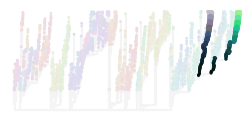

teeplots/2026-03-12-btr-clade-lineage/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.pdf
teeplots/2026-03-12-btr-clade-lineage/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.png


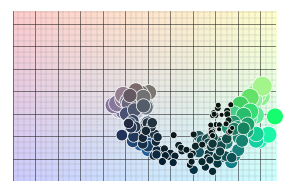

In [9]:
for regime, seed in it.product(
    ("pure",),
    (5,),
):
    df = df_pure.copy()
    df["lay"] = df["layer"] // 10
    # df["target1"] = df["dstream_data_id"] == 1007792754
    # df["target1"] = df["dstream_data_id"] == 1007036283
    df["target1"] = df["dstream_data_id"] == 1009054576
    df["target2"] = df["dstream_data_id"] == 998027862
    df["extant"] = False
    df["extant"] |= pfl.alifestd_mark_sample_tips_lineage_stratified_asexual(
        df,
        criterion_delta="origin_time",
        criterion_stratify="lay",
        criterion_target="target1",
        n_tips_per_stratum=1,
    )["alifestd_mark_sample_tips_lineage_stratified_asexual"]
    df["extant"] |= pfl.alifestd_mark_sample_tips_lineage_stratified_asexual(
        df,
        criterion_delta="origin_time",
        criterion_stratify="lay",
        criterion_target="target2",
        n_tips_per_stratum=1,
    )["alifestd_mark_sample_tips_lineage_stratified_asexual"]
    df["is_lineage"] = df["extant"].copy()

    df["extant"] |= pfl.alifestd_mark_sample_tips_uniform_asexual(
        df,
        n_sample=3_000,
    )["alifestd_mark_sample_tips_uniform_asexual"]

    df = df.pipe(pfl.alifestd_prune_extinct_lineages_asexual,).pipe(
        pfl.alifestd_collapse_unifurcations,
    )

    ot_thresh = df.dropna(subset=["origin_time"])["origin_time"].max() * 0.35
    df["x__"] = df["x_"].copy()
    df["y__"] = df["y_"].copy()
    mask = df["is_lineage"] & (df["origin_time"] >= ot_thresh)
    df.loc[~mask, "x_"] = pd.NA
    df.loc[~mask, "y_"] = pd.NA
    for layout in ("vertical",):

        with tp.teed(
            pylib.chloropleth.draw_ctree,
            df,
            x="x__",
            y="y__",
            cmap=lambda *args, **kwargs: sns.set_hls_values(
                pylib.cmap.bcyr.get_color(*args, **kwargs),
                l=0.9,
                s=0.4,
            ),
            layout=layout,
            scatter_kws=dict(
                # alpha=0.3,
                edgecolor="none",
                s=4,
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    color="#f4f4f4",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
            teeplot_outattrs={"regime": regime, "seed": seed},
            teeplot_subdir=teeplot_subdir,
        ) as teed:
            for t1, t2 in reversed([*it.pairwise(np.linspace(0, 1, num=20))]):
                t1_ = t1 * df["origin_time"].max()
                t2_ = t2 * df["origin_time"].max()
                data = df.copy()
                data.loc[
                    ~data["origin_time"].between(t1_, t2_), ["x_", "y_"]
                ] = pd.NA
                pylib.chloropleth.draw_ctree(
                    data,
                    x="x_",
                    y="y_",
                    ax=teed,
                    cmap=lambda *args, **kwargs: sns.set_hls_values(
                        pylib.cmap.bcyr.get_color(*args, **kwargs),
                        l=t2**3 * 0.75,
                        # s=t2,
                    ),
                    layout=layout,
                    scatter_kws=dict(
                        edgecolor="none",
                        s=(4 + 40 * (t2 - 0.3) ** 2),
                    ),
                    scatter_shuffle=1,
                    tree_kws=dict(
                        edge=dict(
                            alpha=0.0,
                            color="#f4f4f4",
                            linewidth=0.5,
                        ),
                        margins=-0.05,
                    ),
                )
            teed.invert_yaxis()
            teed.figure.set_size_inches(3, 1.33)

    with tp.teed(
        pylib.chloropleth.draw_cscatter,
        df.dropna(subset=["x_", "y_"]),
        x="x",
        y="y",
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=25,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            alpha=0,
            s=150,
        ),
        teeplot_outattrs={"cmap": "bcyr", "regime": regime, "seed": seed},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        for t1, t2 in reversed([*it.pairwise(np.linspace(0, 1, num=20))]):
            t1_ = t1 * df["origin_time"].max()
            t2_ = t2 * df["origin_time"].max()
            data = df[df["origin_time"].between(t1_, t2_)].dropna(
                subset=["x_", "y_"]
            )
            pylib.chloropleth.draw_cscatter(
                data,
                x="x",
                y="y",
                ax=teed,
                cmap=lambda *args, **kwargs: sns.set_hls_values(
                    pylib.cmap.bcyr.get_color(*args, **kwargs),
                    l=t2**3 * 0.75,
                    # s=t2,
                ),
                cgrid=False,
                despine=True,
                # major=100,
                # minor=25,
                xmax=1170,
                ymax=755,
                cgrid_kws=dict(
                    alpha=0.0,
                ),
                rect_kws=dict(
                    alpha=0.0,
                    edgecolor="none",
                ),
                scatter_kws=dict(
                    alpha=1,
                    s=t2**2.8 * 200,
                    edgecolor="white",
                    linewidth=0.5,
                    zorder=500,
                ),
            )

        teed.set_aspect("equal")
        fig = teed.figure
        fig.set_size_inches(3, 2)
        fig.tight_layout()


## Combined plots


teeplots/2026-03-12-btr-clade-lineage/viz=subplots+ext=.pdf
teeplots/2026-03-12-btr-clade-lineage/viz=subplots+ext=.png


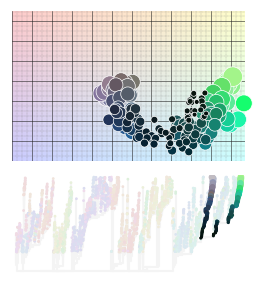

In [10]:
with tp.teed(
    plt.subplots,
    ncols=1,
    nrows=2,
    figsize=(3, 4),
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.1, "wspace": 0.05},
    teeplot_subdir=teeplot_subdir,
) as fig:
    fig, axs = fig

    pylib.chloropleth.draw_ctree(
        df,
        x="x__",
        y="y__",
        ax=axs[1],
        cmap=lambda *args, **kwargs: sns.set_hls_values(
            pylib.cmap.bcyr.get_color(*args, **kwargs),
            l=0.9,
            s=0.4,
        ),
        layout=layout,
        scatter_kws=dict(
            # alpha=0.3,
            edgecolor="none",
            s=4,
        ),
        scatter_shuffle=1,
        tree_kws=dict(
            edge=dict(
                color="#f4f4f4",
                linewidth=0.5,
            ),
            margins=-0.05,
        ),
    )
    for t1, t2 in reversed([*it.pairwise(np.linspace(0, 1, num=20))]):
        t1_ = t1 * df["origin_time"].max()
        t2_ = t2 * df["origin_time"].max()
        data = df.copy()
        data.loc[~data["origin_time"].between(t1_, t2_), ["x_", "y_"]] = pd.NA
        pylib.chloropleth.draw_ctree(
            data,
            x="x_",
            y="y_",
            ax=axs[1],
            cmap=lambda *args, **kwargs: sns.set_hls_values(
                pylib.cmap.bcyr.get_color(*args, **kwargs),
                l=t2**3 * 0.75,
                # s=t2,
            ),
            layout=layout,
            scatter_kws=dict(
                edgecolor="none",
                s=(4 + 40 * (t2 - 0.3) ** 2),
            ),
            scatter_shuffle=1,
            tree_kws=dict(
                edge=dict(
                    alpha=0.0,
                    color="#f4f4f4",
                    linewidth=0.5,
                ),
                margins=-0.05,
            ),
        )
    axs[1].invert_yaxis()
    axs[1].set_anchor("N")

    pylib.chloropleth.draw_cscatter(
        df.dropna(subset=["x_", "y_"]),
        x="x",
        y="y",
        ax=axs[0],
        cmap=pylib.cmap.bcyr.get_color,
        despine=True,
        major=100,
        minor=25,
        xmax=1170,
        ymax=755,
        scatter_kws=dict(
            alpha=0,
            s=150,
        ),
    )
    for t1, t2 in reversed([*it.pairwise(np.linspace(0, 1, num=20))]):
        t1_ = t1 * df["origin_time"].max()
        t2_ = t2 * df["origin_time"].max()
        data = df[df["origin_time"].between(t1_, t2_)].dropna(
            subset=["x_", "y_"]
        )
        pylib.chloropleth.draw_cscatter(
            data,
            x="x",
            y="y",
            ax=axs[0],
            cmap=lambda *args, **kwargs: sns.set_hls_values(
                pylib.cmap.bcyr.get_color(*args, **kwargs),
                l=t2**3 * 0.75,
                # s=t2,
            ),
            cgrid=False,
            despine=True,
            xmax=1170,
            ymax=755,
            cgrid_kws=dict(
                alpha=0.0,
            ),
            rect_kws=dict(
                alpha=0.0,
                edgecolor="none",
            ),
            scatter_kws=dict(
                alpha=1,
                s=t2**2.8 * 200,
                edgecolor="white",
                linewidth=0.5,
                zorder=500,
            ),
        )

    axs[0].set_xlabel(None)
    axs[0].set_ylabel(None)
    axs[0].set_aspect("equal", anchor="S")


In [11]:
import pymupdf

spatial_positions_path = (
    "assets/2026-03-04-wse-spatial-phylo-singleton-positions.pdf"
)
spatial_template_path = (
    "assets/2026-03-04-wse-spatial-phylo-singleton-template.pdf"
)

spatial_positions_doc = pymupdf.open(spatial_positions_path)
print(
    f"Positions: {len(spatial_positions_doc)} page(s), size {spatial_positions_doc[0].rect}"
)

spatial_template_doc = pymupdf.open(spatial_template_path)
print(
    f"Template:  {len(spatial_template_doc)} page(s), size {spatial_template_doc[0].rect}"
)


Positions: 1 page(s), size Rect(0.0, 0.0, 413.5670471191406, 279.6712341308594)
Template:  1 page(s), size Rect(0.0, 0.0, 413.5670471191406, 279.6712341308594)


In [12]:
spatial_target_colors = {
    # "accede": "#ACCEDE",
    "beefed": "#BEEFED",
    # "decade": "#DECADE",
    "deadbe": "#DEADBE",
}


def hex_to_rgb_float(hex_color):
    h = hex_color.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255.0 for i in (0, 2, 4))


def find_rects_by_color(page, hex_color, tol=2 / 255):
    target = hex_to_rgb_float(hex_color)
    rects = []
    for path in page.get_drawings():
        fill = path.get("fill")
        if fill is None or len(fill) != 3:
            continue
        if all(abs(fill[i] - target[i]) < tol for i in range(3)):
            rects.append(path["rect"])
    return rects


spatial_positions_page = spatial_positions_doc[0]
spatial_color_rects = {}
for name, hex_color in spatial_target_colors.items():
    rects = find_rects_by_color(spatial_positions_page, hex_color)
    spatial_color_rects[name] = rects
    for r in rects:
        print(f"  {name} ({hex_color}): {r}")


  beefed (#BEEFED): Rect(161.38299560546875, 23.645000457763672, 382.25, 169.08599853515625)
  deadbe (#DEADBE): Rect(161.87899780273438, 168.78900146484375, 382.7460021972656, 279.6719970703125)


In [13]:
spatial_plot_paths = {
    # "accede": "cmap=bcyr+regime=pure+seed=0+viz=draw-cscatter+x=x+y=y+ext=.pdf",
    "beefed": "cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.pdf",
    # "decade": "layout=vertical+regime=pure-mask+seed=0+viz=draw-ctree+x=x+y=y+ext=.pdf",
    "deadbe": "layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf",
}

spatial_plot_docs = {}
for name, filename in spatial_plot_paths.items():
    path = os.path.join("teeplots", teeplot_subdir, filename)
    print(f"Loading {name} from: {path}")
    spatial_plot_docs[name] = pymupdf.open(path)

page = spatial_template_doc[0]
for name, rects in spatial_color_rects.items():
    src_doc = spatial_plot_docs[name]
    delta = {
        "accede": 11,
        "beefed": 11,
        "decade": 5,
        "deadbe": 5,
    }[name]
    for rect in rects:
        rect.y0 -= delta + 7 * name.startswith("de")
        rect.x0 -= delta
        rect.y1 += delta - 7 * name.startswith("de")
        rect.x1 += delta
        page.show_pdf_page(rect, src_doc, 0)
        print(f"  Inserted {name} at {rect}")

# set Interpolate on all raster images so PDF viewers use smooth scaling
for img in page.get_images(full=True):
    xref = img[0]
    if "/Interpolate" not in spatial_template_doc.xref_object(xref):
        spatial_template_doc.xref_set_key(xref, "Interpolate", "true")

spatial_output_destination = f"teeplots/{teeplot_subdir}/"
os.makedirs(spatial_output_destination, exist_ok=True)
spatial_output_path = os.path.join(
    spatial_output_destination,
    "wse-spatial-singleton-phylo-filled.pdf",
)
spatial_template_doc.save(spatial_output_path, garbage=4, deflate=True)
spatial_template_doc.close()
for d in spatial_plot_docs.values():
    d.close()
print(f"\nSaved to {spatial_output_path}")


Loading beefed from: teeplots/2026-03-12-btr-clade-lineage/cmap=bcyr+regime=pure+seed=5+viz=draw-cscatter+x=x+y=y+ext=.pdf
Loading deadbe from: teeplots/2026-03-12-btr-clade-lineage/layout=vertical+regime=pure+seed=5+viz=draw-ctree+x=x+y=y+ext=.pdf
  Inserted beefed at Rect(150.38299560546875, 12.645000457763672, 393.25, 180.08599853515625)
  Inserted deadbe at Rect(156.87899780273438, 156.78900146484375, 387.7460021972656, 277.6719970703125)

Saved to teeplots/2026-03-12-btr-clade-lineage/wse-spatial-singleton-phylo-filled.pdf


In [14]:
spatial_filled_doc = pymupdf.open(spatial_output_path)
dpi = 600
mat = pymupdf.Matrix(dpi / 72, dpi / 72)
pix = spatial_filled_doc[0].get_pixmap(matrix=mat, alpha=False)
spatial_png_path = spatial_output_path.replace(".pdf", ".png")
pix.save(spatial_png_path)
spatial_filled_doc.close()
print(f"Saved {pix.width}x{pix.height} @ {dpi} DPI to {spatial_png_path}")


Saved 3447x2331 @ 600 DPI to teeplots/2026-03-12-btr-clade-lineage/wse-spatial-singleton-phylo-filled.png
